In [35]:
### Hayden Gallo
### Bucci Lab
### Plotting flux sampling data from hpc simulations
### 7/22/25

import numpy as np
#from dfba import DfbaModel, ExchangeFlux, KineticVariable
import cobra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from numba import njit
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import sys
import os
import openpyxl
import gurobipy

import pymc as pm
import pytensor
import pytensor.tensor as pt
from pymc.ode import DifferentialEquation
from pytensor.compile.ops import as_op
import arviz as az

import time
import joblib
import multiprocessing
from scipy.stats import truncnorm
import copy
from pathlib import Path
import subprocess

### script for running glv_dfba inference
from helper_functions import *
import itertools
from collections import Counter

import matplotlib.lines as lines
import json
import csv

import plotly.express as px
from paretoset import paretoset

In [2]:
main_directory = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_flux_sampling_test_1/'

In [3]:
### load in dietary and initial metabolite data for filtering 

### change over init values to correct kbase nomenclature 

metabolomics_data = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/complete_mapping_metabolomics.csv', index_col=0)
## fill NAs w/ zero 
metabolomics_data = metabolomics_data.fillna(0)

    ### load in metabolomics metadata

metabolomics_metadata_raw = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/metabolomics_meta.csv', index_col=0)
# filtered metabolomics metadata for subject 1948 initial sample 
metabolomics_metadata = metabolomics_metadata_raw.copy()
metabolomics_metadata = metabolomics_metadata[(metabolomics_metadata['Mouse'] == float(1948)) & (metabolomics_metadata['Rec_day_adj'] == -3)]
metabolomics_metadata.index.tolist()

metabolomics_data_initial_sub_1948 = metabolomics_data[metabolomics_data['SampleName'] == metabolomics_metadata.index.tolist()[0]]

metabolomics_data_initial_sub_1948.iloc[:,1:].T.index.tolist()

with open('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/BiGG_to_MSID.json') as f:
    bigg_to_modelseed = json.load(f)

cmpd_names = []
for i in metabolomics_data_initial_sub_1948.iloc[:,1:].T.index.tolist():
    cmpd_names.append(bigg_to_modelseed[i])

metabolomics_data_initial_sub_1948 = metabolomics_data_initial_sub_1948.iloc[:,1:].T

metabolomics_data_initial_sub_1948.index = cmpd_names
metabolomics_data_initial_sub_1948.reset_index(inplace=True)
metabolomics_data_initial_sub_1948.columns = ['reaction', 'fluxValue']

metabolomics_data_initial_sub_1948

for i in range(0, len(metabolomics_data_initial_sub_1948)):
    metabolomics_data_initial_sub_1948['reaction'].iloc[i] = 'EX_' + metabolomics_data_initial_sub_1948['reaction'].iloc[i]  + '_b'

#metabolomics_data_initial_sub_1948  

/var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/ipykernel_6964/4228171968.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  metabolomics_data_initial_sub_1948['reaction'].iloc[i] = 'EX_' + metabolomics_data_initial_sub_1948['reaction'].i

In [4]:
### Reading in all of the data from the simulation 

abun_to_store =[]
met_to_store =[]

conditions = ['Subject_1507_met']#, 'Subject_1953_met', 'Subject_1999_met']
for j, name in enumerate(conditions):
    subdirectory = main_directory + name
    temp_abun = []
    temp_met =[]
    for i in range(0,500):
        
        temp_dir = subdirectory + '/sim_' + str(i) + '_met_save.npy'
        #print(temp_dir)
        if os.path.exists(temp_dir):
            print(temp_dir)
            #met = subdirectory + '/sim_' + str(i) + '_abun_save.npy'
            #abun = temp_dir + '/model_abun_dict.npy'
            met = np.load(temp_dir, allow_pickle=True)
            #abun = np.load(abun, allow_pickle=True)
            temp_met.append(met)
            #temp_abun.append(abun.item())
    #abun_to_store.append(temp_abun)
    met_to_store.append(temp_met)   

/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_flux_sampling_test_1/Subject_1507_met/sim_1_met_save.npy
/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_flux_sampling_test_1/Subject_1507_met/sim_8_met_save.npy
/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_flux_sampling_test_1/Subject_1507_met/sim_9_met_save.npy
/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_flux_sampling_test_1/Subject_1507_met/sim_10_met_save.npy
/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Buc

In [5]:
### set num sim points here

num_sim_pts = 415


# converting our dictionaries to dataframes 

df_met_storage = []
df_stacked_storage=[]
index = []
for j in range(0, len(met_to_store)):
    temp_df_met_storage =[]
    temp_df_stacked_storage =[]
    temp_index = []
    for i in range(0, len(met_to_store[j])):
        test = pd.DataFrame(met_to_store[j][i].tolist())
        test = np.transpose(test)
        test = test.fillna(0)
        diff_df = pd.DataFrame(test.iloc[:,0] - test.iloc[:,num_sim_pts])
        diff_df.columns = ['diff']
        ### this line removes metabolites that don't change overtime at all or at least there is no difference between t=0 and t=f
        # maybe this is unneccessary here 
        test_filt = test[test.index.isin(diff_df[diff_df['diff'] !=0].index)]
        temp_df_stacked_storage.append(test_filt)
        temp_index.append(test_filt.index.tolist())
        test_unstack = test_filt.unstack()
        test_unstack = pd.DataFrame(test_unstack).reset_index()
        test_unstack.columns = ['time', 'reaction', 'fluxValue']
        temp_df_met_storage.append(test_unstack)

    df_met_storage.append(temp_df_met_storage)
    df_stacked_storage.append(temp_df_stacked_storage)
    index.append(temp_index)    

In [6]:
list_df_concat = []

for i in range(0, len(index)):

    index_full = list(itertools.chain.from_iterable(index[i]))
    index_unique = np.unique(index_full).tolist()
    index_full_unique = index_unique * len(df_stacked_storage[i])
    df_concat = pd.concat(df_stacked_storage[i], join='outer')
    df_concat_index = df_concat.index.tolist()
    final = Counter(index_full_unique) - Counter(df_concat_index)
    missing_elems = list(final.elements())
    df_to_append = np.zeros([len(missing_elems), (df_concat.shape[1])])
    df_to_append = pd.DataFrame(df_to_append)
    df_to_append.index = missing_elems
    df_concat = pd.concat([df_concat, df_to_append], join='outer')
    list_df_concat.append(df_concat)

In [7]:
melted_df = list_df_concat[0].melt(ignore_index=False)
melted_df.columns = ['time', 'fluxValue']
melted_df = melted_df.reset_index()
melted_df.columns = ['reaction','time', 'fluxValue']
melted_df = melted_df[melted_df['reaction'].isin(metabolomics_data_initial_sub_1948['reaction'].to_list())]
melted_df

,reaction,time,fluxValue
0,EX_cpd35610_b,0,0.147
1,EX_cpd01242_b,0,0.381
2,EX_cpd01293_b,0,0.637
3,EX_cpd00035_b,0,15.682
4,EX_cpd01055_b,0,0.035
...,...,...,...
10718696,EX_cpd00158_b,415,0.000
10718697,EX_cpd00158_b,415,0.000
10718698,EX_cpd00158_b,415,0.000
10718699,EX_cpd00158_b,415,0.000


In [8]:
#melted_df_sub = melted_df.iloc[:1000000,:]
#melted_df_sub
### put on correct time scale 
melted_df['time'] = (melted_df['time']/24)-3

NameError: name 'melted_df_sub' is not defined

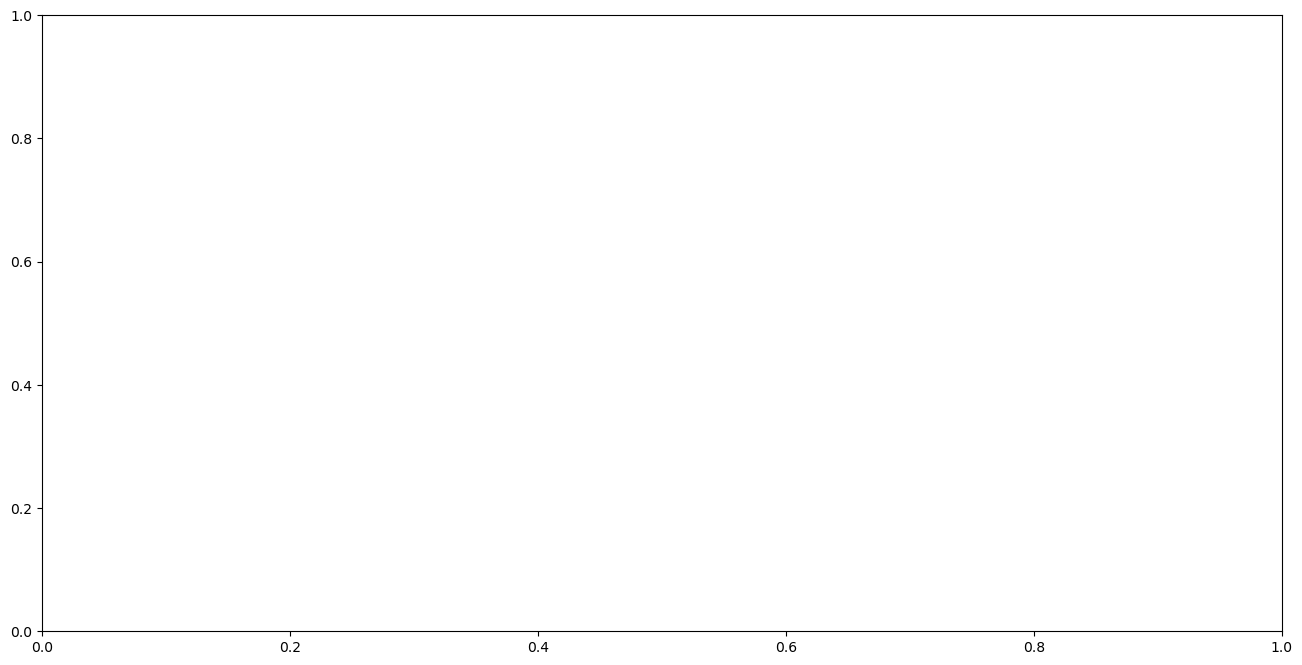

In [9]:
# Your existing lineplot
fig, axs = plt.subplots(figsize= (16,8))
sns.lineplot(data=melted_df_sub, x='time', y='fluxValue', hue='reaction')
plt.yscale('log')

In [10]:
### Here plot the metabolomics data 
metabolomics_metadata_raw = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/metabolomics_meta.csv', index_col=0)


metabolomics_metadata_sub_1948 = metabolomics_metadata_raw[metabolomics_metadata_raw['Mouse'] == float(1510)]
metabolomics_metadata_sub_1948

met_days_1948_dict = dict(zip(metabolomics_metadata_sub_1948.index.tolist(),metabolomics_metadata_sub_1948['Rec_day_adj'].tolist() ))
met_days_1948_dict

metabolomics_data_sub_1948 = metabolomics_data[metabolomics_data['SampleName'].isin(met_days_1948_dict.keys())]
metabolomics_data_sub_1948 = metabolomics_data_sub_1948.set_index('SampleName')

metabolomics_data_sub_1948 = metabolomics_data_sub_1948.T

metabolomics_data_sub_1948.columns = np.sort(list(met_days_1948_dict.values()))
metabolomics_data_sub_1948

#change_met_ids = bigg_to_agora_exchange_ids(metabolomics_data_sub_1948_ra.index.tolist())
change_met_ids = []
for i in metabolomics_data_sub_1948.index.tolist():
    change_met_ids.append('EX_' + bigg_to_modelseed[i] + '_b')
#metabolomics_data_sub_1948.index = change_met_ids
#metabolomics_data_sub_1948_ra.head()

#change_met_ids = bigg_to_agora_exchange_ids(metabolomics_data_sub_1948.index.tolist())
metabolomics_data_sub_1948.index = change_met_ids
metabolomics_data_sub_1948.head()

,-3,0,3,5,7,11,14
EX_cpd35610_b,0.147,0.000,0.000,0.000,0.000,0.152,0.020
EX_cpd01242_b,0.381,0.035,0.032,0.116,0.060,0.160,0.294
EX_cpd01293_b,0.637,0.847,0.831,1.356,1.196,0.494,1.440
EX_cpd00035_b,15.682,1.438,0.470,3.707,3.932,13.743,18.268
EX_cpd01055_b,0.035,0.165,0.135,0.248,0.148,0.066,1.549


IndexError: index 70 is out of bounds for axis 0 with size 70

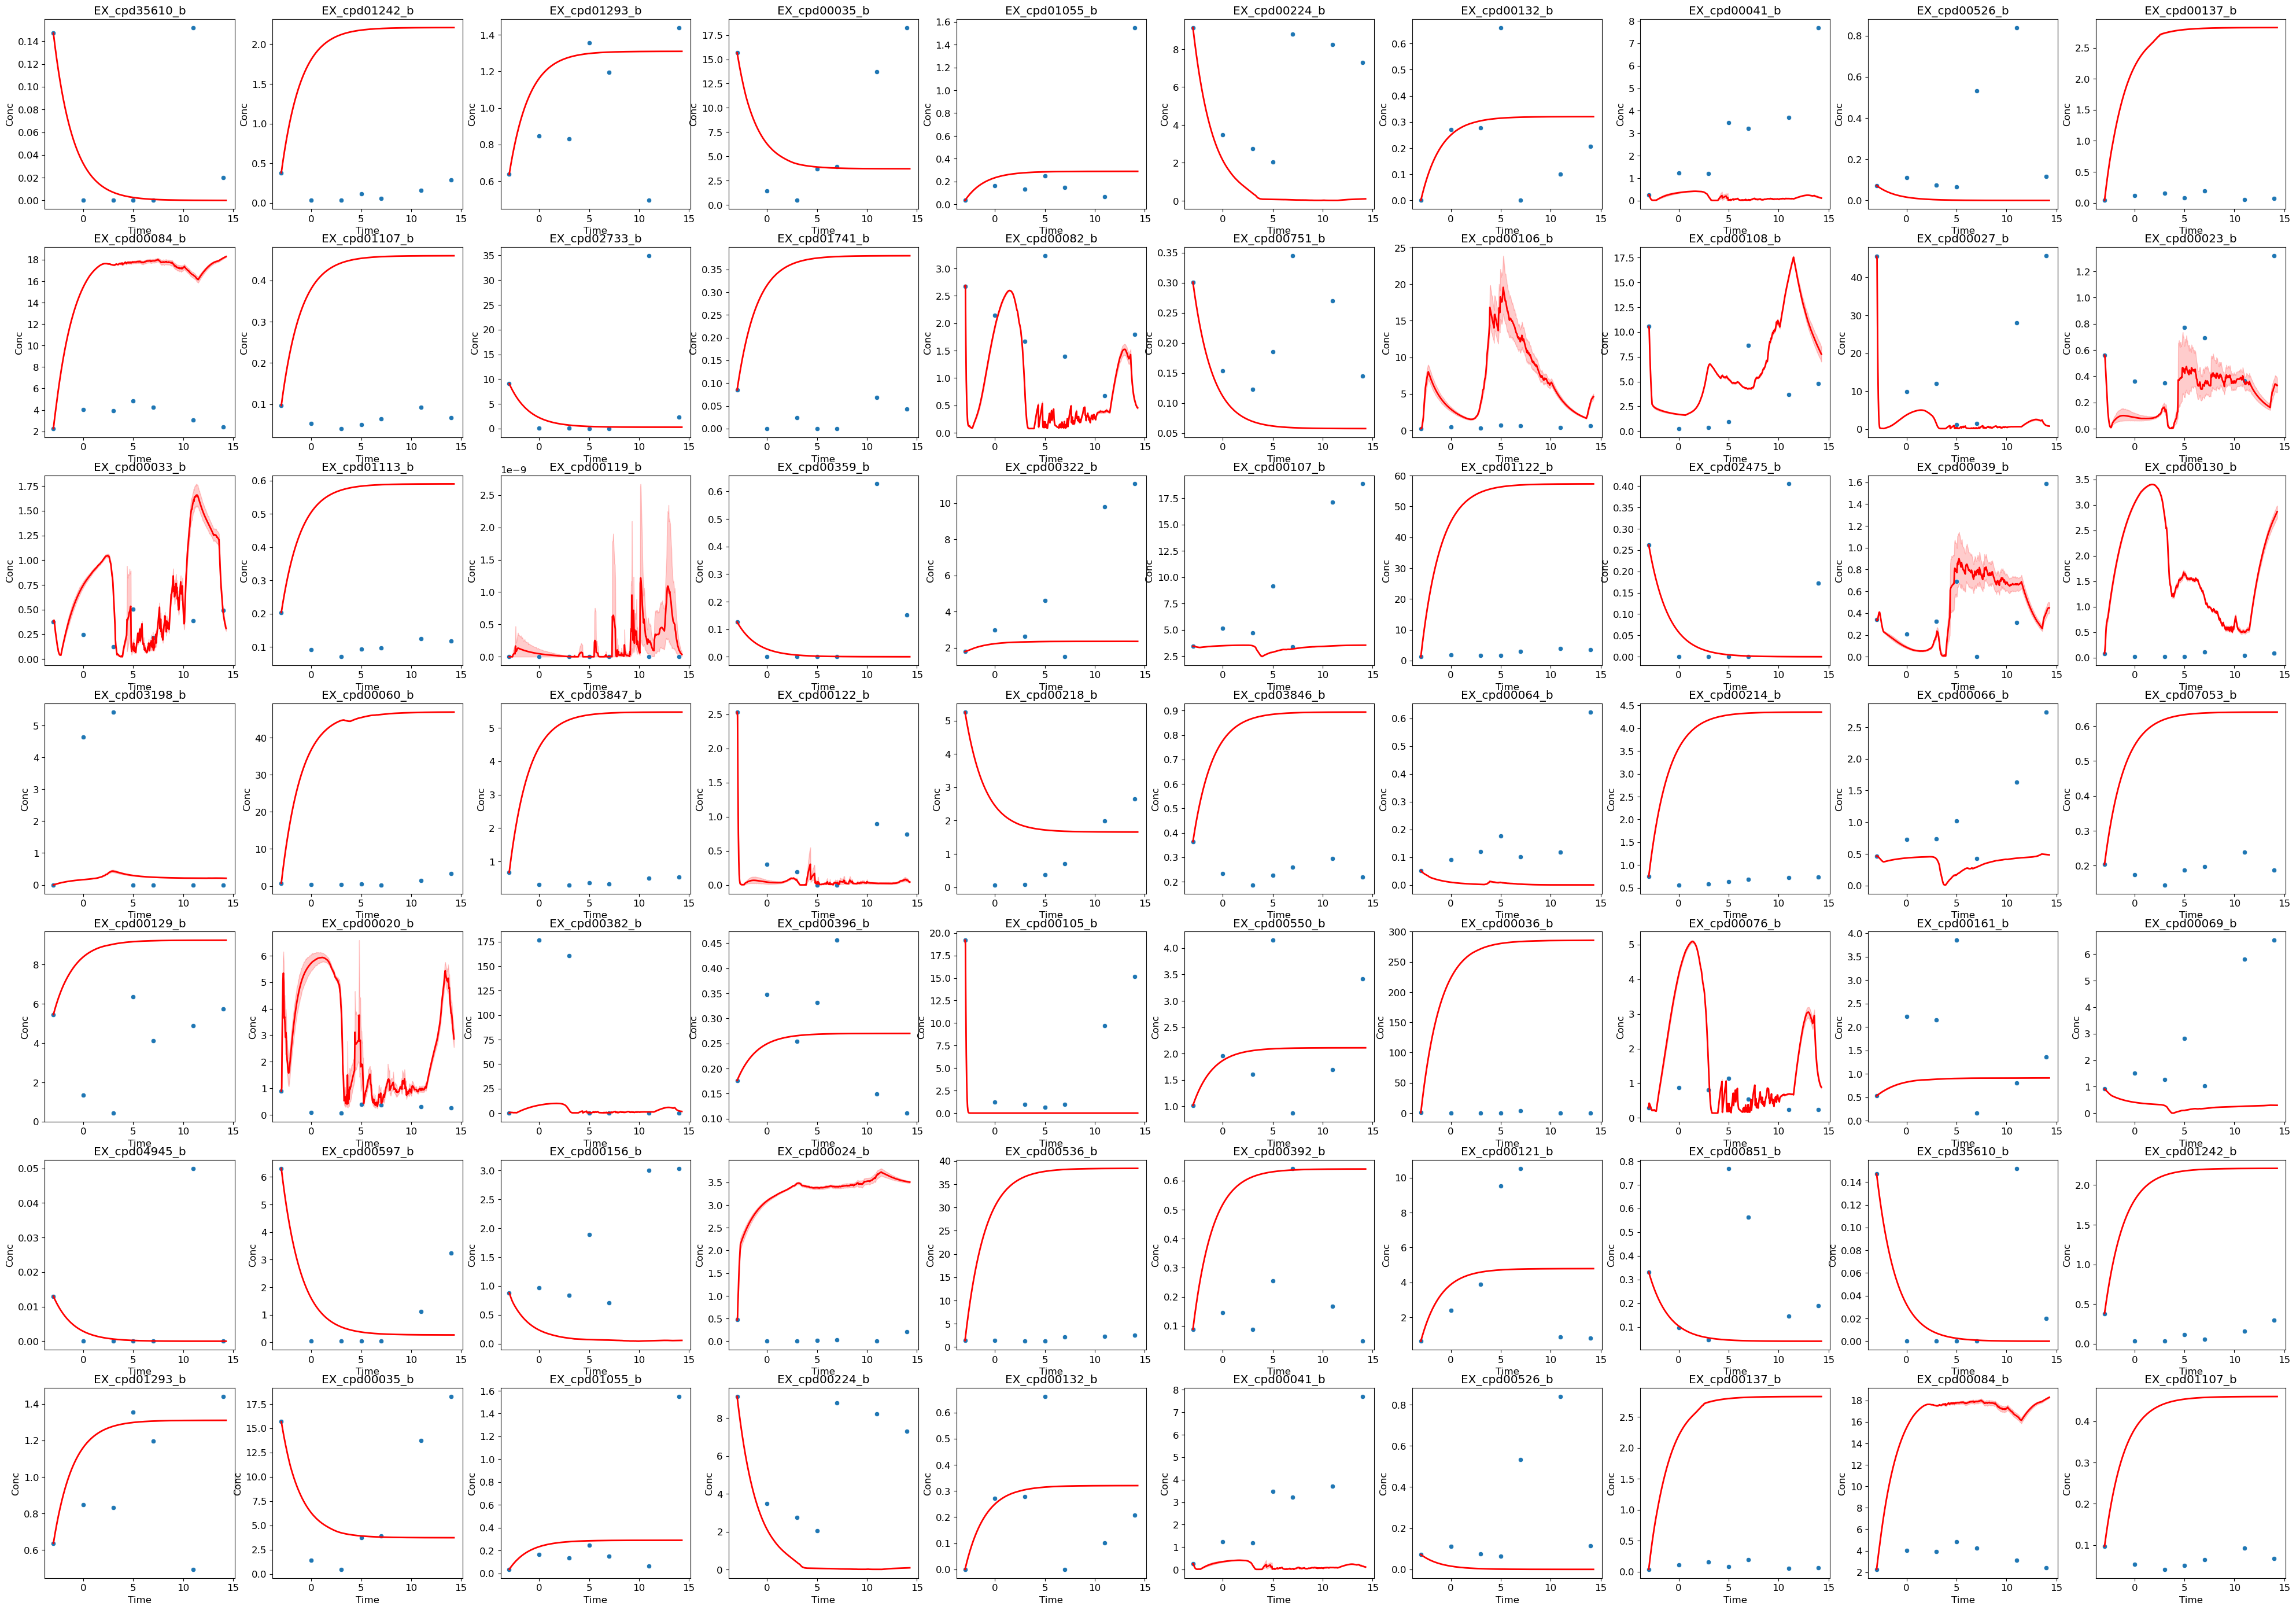

In [112]:
num_plots = 61
cols = 10  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i,met in enumerate(melted_df['reaction'].to_list()):
    temp_sim = melted_df[melted_df['reaction'] == met]
    temp_exp = metabolomics_data_sub_1948.loc[met,:]
        # Scatter plot on the respective subplot
    sns.lineplot(ax=axes[i], data = temp_sim, x='time', y='fluxValue', color = 'red', lw = 2)
    sns.scatterplot(ax=axes[i], 
                        x=temp_exp.index.to_list(), y=temp_exp.to_list())

    axes[i].set_title(f"{met}")
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Conc')
    #axes[i].set_yscale('log')
    #axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

In [75]:
### Here create pareto front for Monte Carlo Constraint FBA 

### Reading in all of the data from the simulation 
import ast
MC_constraint_directory = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_MC_FBA_constraints_test_1/'

met_rmse =[]
abun_rmse =[]
num_constraints = []
constraints = []
sim_num = []

conditions = ['Subject_1507_rmse']#, 'Subject_1953_rmse', 'Subject_1999_rmse']
for j, name in enumerate(conditions):
    subdirectory = MC_constraint_directory + name
    temp_abun = []
    temp_met =[]
    for i in range(0,15000):
        
        temp_dir = subdirectory + '/rmse_dict_' + str(i) + '.csv'
        #print(temp_dir)
        if os.path.exists(temp_dir):
            #print(temp_dir)
            
            with open(temp_dir, 'r') as f:
                data_dict = json.load(f)
            met_rmse.append(data_dict['total_rmse'])
            constraints.append(data_dict['mets_constrained'])
            num_constraints.append(len(data_dict['mets_constrained']))
            abun_rmse.append(data_dict['rmse_MDSINE_vs_FBA'])
            sim_name = str(i)
            sim_num.append(sim_name)
            

            


In [76]:
data = list(zip(met_rmse, abun_rmse, num_constraints, constraints, sim_num))
mc_constraint_df = pd.DataFrame(data, columns=['met_rmse', 'abun_rmse', 'num_constraints', 'constraints', 'sim_num'])
mc_constraint_df

,met_rmse,abun_rmse,num_constraints,constraints,sim_num
0,13.894265,5.726512e+10,5,"[EX_cpd01107_b, EX_cpd01122_b, EX_cpd00322_b, ...",0
1,12.382424,5.824220e+10,10,"[EX_cpd02733_b, EX_cpd00359_b, EX_cpd00121_b, ...",3
2,inf,4.800939e+10,8,"[EX_cpd00036_b, EX_cpd00224_b, EX_cpd03847_b, ...",4
3,14.430012,5.697875e+10,2,"[EX_cpd01055_b, EX_cpd00161_b]",6
4,12.771228,5.767040e+10,2,"[EX_cpd00597_b, EX_cpd00060_b]",9
...,...,...,...,...,...
9067,13.248564,5.457049e+10,1,[EX_cpd00119_b],14994
9068,14.215128,5.454372e+10,5,"[EX_cpd01293_b, EX_cpd07053_b, EX_cpd00064_b, ...",14995
9069,16.235190,4.761746e+10,9,"[EX_cpd00041_b, EX_cpd00597_b, EX_cpd04945_b, ...",14997
9070,13.838924,5.603110e+10,8,"[EX_cpd00161_b, EX_cpd01171_b, EX_cpd00069_b, ...",14998


In [77]:
mc_constraint_df_filt = mc_constraint_df[mc_constraint_df['met_rmse'] != np.inf]

In [78]:
mc_constraint_df_filt.dtypes

met_rmse           float64
abun_rmse          float64
num_constraints      int64
constraints         object
sim_num             object
dtype: object

In [79]:
mc_constraint_df_filt_reduced = mc_constraint_df_filt.drop(columns=['constraints', 'sim_num'])

### determine pareto front
mask = paretoset(mc_constraint_df_filt_reduced, sense =['min', 'min', 'min'])
mc_constraint_df_filt['pareto'] = mask
mc_constraint_df_filt

/var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/ipykernel_6964/260515825.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,met_rmse,abun_rmse,num_constraints,constraints,sim_num,pareto
0,13.894265,5.726512e+10,5,"[EX_cpd01107_b, EX_cpd01122_b, EX_cpd00322_b, ...",0,False
1,12.382424,5.824220e+10,10,"[EX_cpd02733_b, EX_cpd00359_b, EX_cpd00121_b, ...",3,False
3,14.430012,5.697875e+10,2,"[EX_cpd01055_b, EX_cpd00161_b]",6,False
4,12.771228,5.767040e+10,2,"[EX_cpd00597_b, EX_cpd00060_b]",9,False
5,13.667317,5.764086e+10,3,"[EX_cpd01113_b, EX_cpd07053_b, EX_cpd01242_b]",10,False
...,...,...,...,...,...,...
9067,13.248564,5.457049e+10,1,[EX_cpd00119_b],14994,False
9068,14.215128,5.454372e+10,5,"[EX_cpd01293_b, EX_cpd07053_b, EX_cpd00064_b, ...",14995,False
9069,16.235190,4.761746e+10,9,"[EX_cpd00041_b, EX_cpd00597_b, EX_cpd04945_b, ...",14997,False
9070,13.838924,5.603110e+10,8,"[EX_cpd00161_b, EX_cpd01171_b, EX_cpd00069_b, ...",14998,False


In [80]:
import plotly.graph_objects as go
import numpy as np
from scipy.spatial import ConvexHull
from scipy.interpolate import griddata

# Create a figure
fig = go.Figure()

# Add scatter points for all data
fig.add_trace(go.Scatter3d(
    x=mc_constraint_df_filt['met_rmse'],
    y=np.log10(mc_constraint_df_filt['abun_rmse']),
    z=mc_constraint_df_filt['num_constraints'],
    mode='markers',
    marker=dict(
        size=2,
        color=mc_constraint_df_filt['pareto'].astype(int),  # Convert boolean to int for coloring
        colorscale=[[0, 'blue'], [1, 'red']],  # Blue for non-Pareto, red for Pareto
        opacity=0.2
    ),
    name='All Points'
))

# Filter only Pareto points
pareto_points = mc_constraint_df_filt[mc_constraint_df_filt['pareto'] == True]

# Extract coordinates of Pareto points
x = pareto_points['met_rmse'].values
y = np.log10(pareto_points['abun_rmse'].values)
z = pareto_points['num_constraints'].values
#pareto_sims = np.int64(pareto_points['sim_num'].values)

# Create a 2D surface for the Pareto front
if len(x) >= 4:
    # Create a grid for interpolation
    xi = np.linspace(min(x), max(x), 50)
    yi = np.linspace(min(y), max(y), 50)
    X, Y = np.meshgrid(xi, yi)
    
    # Interpolate z values over the grid
    points = np.vstack((x, y)).T
    Z = griddata(points, z, (X, Y), method='linear')
    
    color1 = 'orange'

    # Create the surface
    fig.add_trace(go.Surface(
        x=X,
        y=Y,
        z=Z,
        colorscale=[[0, color1], [1,color1]],
        opacity=0.8,
        showscale=False,
        name='Pareto Surface'
    ))
    
    # Add scatter points just for the Pareto optimal points to make them stand out
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        #hovertext=[f"sim_num={v:.3f}" for v in pareto_sims],
        mode='markers',
        marker=dict(
            size=7,
            color='red',
            symbol='circle'
        ),
        name='Pareto Points'
    ))

# Update the layout to make the figure cube-shaped
fig.update_layout(
    title='3D Pareto Front with 2D Surface',
    scene=dict(
        xaxis_title='Met RMSE',
        yaxis_title='MDSINE vs MDSINE-FBA RMSE',
        zaxis_title='Num Constraints',
        aspectmode='cube'  # Make the display cube-shaped
    ),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    ),
    margin=dict(l=0, r=0, b=0, t=30),
    height=800,
    width=800  # Match height for a perfect cube display
)




# Show the figure
fig.show()

In [81]:
subject_1507_pareto_points = mc_constraint_df_filt[mc_constraint_df_filt['pareto'] == True]

In [82]:
### Here create pareto front for Monte Carlo Constraint FBA 

### Reading in all of the data from the simulation 
import ast
MC_constraint_directory = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_MC_FBA_constraints_test_1/'

met_rmse =[]
abun_rmse =[]
num_constraints = []
constraints = []
sim_num = []

conditions = ['Subject_1953_rmse']#, 'Subject_1999_rmse']
for j, name in enumerate(conditions):
    subdirectory = MC_constraint_directory + name
    temp_abun = []
    temp_met =[]
    for i in range(0,15000):
        
        temp_dir = subdirectory + '/rmse_dict_' + str(i) + '.csv'
        #print(temp_dir)
        if os.path.exists(temp_dir):
            #print(temp_dir)
            
            with open(temp_dir, 'r') as f:
                data_dict = json.load(f)
            met_rmse.append(data_dict['total_rmse'])
            constraints.append(data_dict['mets_constrained'])
            num_constraints.append(len(data_dict['mets_constrained']))
            abun_rmse.append(data_dict['rmse_MDSINE_vs_FBA'])
            sim_name = str(i)
            sim_num.append(sim_name)
            
data = list(zip(met_rmse, abun_rmse, num_constraints, constraints, sim_num))
mc_constraint_df = pd.DataFrame(data, columns=['met_rmse', 'abun_rmse', 'num_constraints', 'constraints', 'sim_num'])
mc_constraint_df

mc_constraint_df_filt = mc_constraint_df[mc_constraint_df['met_rmse'] != np.inf]

mc_constraint_df_filt_reduced = mc_constraint_df_filt.drop(columns=['constraints', 'sim_num'])

### determine pareto front
mask = paretoset(mc_constraint_df_filt_reduced, sense =['min', 'min', 'min'])
mc_constraint_df_filt['pareto'] = mask
mc_constraint_df_filt
            
# Create a figure
fig = go.Figure()

# Add scatter points for all data
fig.add_trace(go.Scatter3d(
    x=mc_constraint_df_filt['met_rmse'],
    y=np.log10(mc_constraint_df_filt['abun_rmse']),
    z=mc_constraint_df_filt['num_constraints'],
    mode='markers',
    marker=dict(
        size=2,
        color=mc_constraint_df_filt['pareto'].astype(int),  # Convert boolean to int for coloring
        colorscale=[[0, 'blue'], [1, 'red']],  # Blue for non-Pareto, red for Pareto
        opacity=0.2
    ),
    name='All Points'
))

# Filter only Pareto points
pareto_points = mc_constraint_df_filt[mc_constraint_df_filt['pareto'] == True]

# Extract coordinates of Pareto points
x = pareto_points['met_rmse'].values
y = np.log10(pareto_points['abun_rmse'].values)
z = pareto_points['num_constraints'].values
#pareto_sims = np.int64(pareto_points['sim_num'].values)

# Create a 2D surface for the Pareto front
if len(x) >= 4:
    # Create a grid for interpolation
    xi = np.linspace(min(x), max(x), 50)
    yi = np.linspace(min(y), max(y), 50)
    X, Y = np.meshgrid(xi, yi)
    
    # Interpolate z values over the grid
    points = np.vstack((x, y)).T
    Z = griddata(points, z, (X, Y), method='linear')
    
    color1 = 'orange'

    # Create the surface
    fig.add_trace(go.Surface(
        x=X,
        y=Y,
        z=Z,
        colorscale=[[0, color1], [1,color1]],
        opacity=0.8,
        showscale=False,
        name='Pareto Surface'
    ))
    
    # Add scatter points just for the Pareto optimal points to make them stand out
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        #hovertext=[f"sim_num={v:.3f}" for v in pareto_sims],
        mode='markers',
        marker=dict(
            size=7,
            color='red',
            symbol='circle'
        ),
        name='Pareto Points'
    ))

# Update the layout to make the figure cube-shaped
fig.update_layout(
    title='3D Pareto Front with 2D Surface',
    scene=dict(
        xaxis_title='Met RMSE',
        yaxis_title='MDSINE vs MDSINE-FBA RMSE',
        zaxis_title='Num Constraints',
        aspectmode='cube'  # Make the display cube-shaped
    ),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    ),
    margin=dict(l=0, r=0, b=0, t=30),
    height=800,
    width=800  # Match height for a perfect cube display
)




# Show the figure
fig.show()

/var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/ipykernel_6964/3996408168.py:44: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [83]:
subject_1953_pareto_points = mc_constraint_df_filt[mc_constraint_df_filt['pareto'] == True]

In [85]:
### Here create pareto front for Monte Carlo Constraint FBA 

### Reading in all of the data from the simulation 
import ast
#MC_constraint_directory = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/hpc_MC_FBA_constraints_test_1/'

met_rmse =[]
abun_rmse =[]
num_constraints = []
constraints = []
sim_num = []

conditions = ['Subject_1999_rmse']
for j, name in enumerate(conditions):
    subdirectory = MC_constraint_directory + name
    temp_abun = []
    temp_met =[]
    for i in range(0,15000):
        
        temp_dir = subdirectory + '/rmse_dict_' + str(i) + '.csv'
        #print(temp_dir)
        if os.path.exists(temp_dir):
            #print(temp_dir)
            
            with open(temp_dir, 'r') as f:
                data_dict = json.load(f)
            met_rmse.append(data_dict['total_rmse'])
            constraints.append(data_dict['mets_constrained'])
            num_constraints.append(len(data_dict['mets_constrained']))
            abun_rmse.append(data_dict['rmse_MDSINE_vs_FBA'])
            sim_name = str(i)
            sim_num.append(sim_name)
            
data = list(zip(met_rmse, abun_rmse, num_constraints, constraints, sim_num))
mc_constraint_df = pd.DataFrame(data, columns=['met_rmse', 'abun_rmse', 'num_constraints', 'constraints', 'sim_num'])
mc_constraint_df

mc_constraint_df_filt = mc_constraint_df[mc_constraint_df['met_rmse'] != np.inf]

mc_constraint_df_filt_reduced = mc_constraint_df_filt.drop(columns=['constraints', 'sim_num'])

### determine pareto front
mask = paretoset(mc_constraint_df_filt_reduced, sense =['min', 'min', 'min'])
mc_constraint_df_filt['pareto'] = mask
mc_constraint_df_filt
            
# Create a figure
fig = go.Figure()

# Add scatter points for all data
fig.add_trace(go.Scatter3d(
    x=mc_constraint_df_filt['met_rmse'],
    y=np.log10(mc_constraint_df_filt['abun_rmse']),
    z=mc_constraint_df_filt['num_constraints'],
    mode='markers',
    marker=dict(
        size=2,
        color=mc_constraint_df_filt['pareto'].astype(int),  # Convert boolean to int for coloring
        colorscale=[[0, 'blue'], [1, 'red']],  # Blue for non-Pareto, red for Pareto
        opacity=0.2
    ),
    name='All Points'
))

# Filter only Pareto points
pareto_points = mc_constraint_df_filt[mc_constraint_df_filt['pareto'] == True]

# Extract coordinates of Pareto points
x = pareto_points['met_rmse'].values
y = np.log10(pareto_points['abun_rmse'].values)
z = pareto_points['num_constraints'].values
#pareto_sims = np.int64(pareto_points['sim_num'].values)

# Create a 2D surface for the Pareto front
if len(x) >= 4:
    # Create a grid for interpolation
    xi = np.linspace(min(x), max(x), 50)
    yi = np.linspace(min(y), max(y), 50)
    X, Y = np.meshgrid(xi, yi)
    
    # Interpolate z values over the grid
    points = np.vstack((x, y)).T
    Z = griddata(points, z, (X, Y), method='linear')
    
    color1 = 'orange'

    # Create the surface
    fig.add_trace(go.Surface(
        x=X,
        y=Y,
        z=Z,
        colorscale=[[0, color1], [1,color1]],
        opacity=0.8,
        showscale=False,
        name='Pareto Surface'
    ))
    
    # Add scatter points just for the Pareto optimal points to make them stand out
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        #hovertext=[f"sim_num={v:.3f}" for v in pareto_sims],
        mode='markers',
        marker=dict(
            size=7,
            color='red',
            symbol='circle'
        ),
        name='Pareto Points'
    ))

# Update the layout to make the figure cube-shaped
fig.update_layout(
    title='3D Pareto Front with 2D Surface',
    scene=dict(
        xaxis_title='Met RMSE',
        yaxis_title='MDSINE vs MDSINE-FBA RMSE',
        zaxis_title='Num Constraints',
        aspectmode='cube'  # Make the display cube-shaped
    ),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    ),
    margin=dict(l=0, r=0, b=0, t=30),
    height=800,
    width=800  # Match height for a perfect cube display
)




# Show the figure
fig.show()

/var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/ipykernel_6964/2610064207.py:44: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [86]:
subject_1999_pareto_points = mc_constraint_df_filt[mc_constraint_df_filt['pareto'] == True]
subject_1999_pareto_points

,met_rmse,abun_rmse,num_constraints,constraints,sim_num,pareto
13,2.237451,2.458825e+10,5,"[EX_cpd00137_b, EX_cpd00027_b, EX_cpd00156_b, ...",21,True
31,9.190659,1.185739e+10,2,"[EX_cpd00526_b, EX_cpd00041_b]",66,True
79,12.702843,1.017472e+10,8,"[EX_cpd00069_b, EX_cpd07053_b, EX_cpd00035_b, ...",160,True
143,8.438748,1.261566e+10,1,[EX_cpd00041_b],279,True
227,8.401979,1.416323e+10,1,[EX_cpd00041_b],460,True
418,7.732090,1.661064e+10,1,[EX_cpd00041_b],893,True
426,2.064244,2.321452e+10,9,"[EX_cpd00060_b, EX_cpd01171_b, EX_cpd00396_b, ...",910,True
548,9.186512,1.152774e+10,4,"[EX_cpd00526_b, EX_cpd00060_b, EX_cpd00041_b, ...",1176,True
573,2.666403,2.364308e+10,3,"[EX_cpd00536_b, EX_cpd00076_b, EX_cpd00137_b]",1222,True
603,3.387884,1.555461e+10,9,"[EX_cpd00392_b, EX_cpd00130_b, EX_cpd01741_b, ...",1280,True


In [87]:
subject_1953_pareto_points

,met_rmse,abun_rmse,num_constraints,constraints,sim_num,pareto
471,13.706161,3.259187e+10,1,[EX_cpd00041_b],592,True
719,14.432344,3.247853e+10,6,"[EX_cpd00526_b, EX_cpd00105_b, EX_cpd00060_b, ...",915,True
1134,12.550805,3.351509e+10,1,[EX_cpd00041_b],1454,True
1158,4.034261,6.361394e+10,2,"[EX_cpd00076_b, EX_cpd00060_b]",1483,True
1817,4.044281,6.295371e+10,3,"[EX_cpd00550_b, EX_cpd00076_b, EX_cpd00060_b]",2356,True
1821,15.298680,3.250115e+10,1,[EX_cpd00041_b],2360,True
2136,4.030932,6.273598e+10,4,"[EX_cpd00060_b, EX_cpd01741_b, EX_cpd00076_b, ...",2751,True
2286,15.424592,3.246824e+10,4,"[EX_cpd07053_b, EX_cpd00041_b, EX_cpd02475_b, ...",2941,True
2298,13.451744,3.279235e+10,2,"[EX_cpd00041_b, EX_cpd00036_b]",2954,True
2400,2.500187,5.815368e+10,7,"[EX_cpd00033_b, EX_cpd00076_b, EX_cpd00156_b, ...",3091,True


In [88]:
subject_1507_pareto_points

,met_rmse,abun_rmse,num_constraints,constraints,sim_num,pareto
82,6.577516,4.844573e+10,8,"[EX_cpd35610_b, EX_cpd01055_b, EX_cpd00536_b, ...",134,True
533,7.578578,4.802040e+10,4,"[EX_cpd02733_b, EX_cpd00076_b, EX_cpd00027_b, ...",885,True
848,5.304014,5.677510e+10,8,"[EX_cpd00121_b, EX_cpd00033_b, EX_cpd00076_b, ...",1407,True
1177,12.731936,4.682149e+10,5,"[EX_cpd00108_b, EX_cpd02475_b, EX_cpd00041_b, ...",1987,True
1205,3.302327,5.809242e+10,8,"[EX_cpd00130_b, EX_cpd00137_b, EX_cpd00536_b, ...",2026,True
1342,5.779882,5.607192e+10,4,"[EX_cpd00033_b, EX_cpd03847_b, EX_cpd00020_b, ...",2266,True
1507,11.594879,4.760419e+10,2,"[EX_cpd00041_b, EX_cpd00130_b]",2504,True
1806,5.897538,5.830257e+10,2,"[EX_cpd00076_b, EX_cpd00129_b]",2994,True
2083,6.569104,4.999081e+10,5,"[EX_cpd00024_b, EX_cpd00069_b, EX_cpd07053_b, ...",3441,True
2214,6.167315,5.705492e+10,1,[EX_cpd00076_b],3656,True


In [90]:
set_1999
set_1953
set_1507 = 

sims_all_pareto_fronts = set(subject_1507_pareto_points['sim_num'].to_list()).intersection(set(subject_1999_pareto_points['sim_num'].to_list()), set(subject_1953_pareto_points['sim_num'].to_list()))
sims_all_pareto_fronts

set()

In [91]:
sub_1507_constraints = subject_1507_pareto_points['constraints'].to_list()
sub_1953_constraints = subject_1953_pareto_points['constraints'].to_list()
sub_1999_constraints = subject_1999_pareto_points['constraints'].to_list()

sub_1507_constraints_flat = [item for sublist in sub_1507_constraints for item in sublist]
sub_1953_constraints_flat = [item for sublist in sub_1953_constraints for item in sublist]
sub_1999_constraints_flat = [item for sublist in sub_1999_constraints for item in sublist]

# Count occurrences
sub_1507_counts = Counter(sub_1507_constraints_flat)
sub_1953_counts = Counter(sub_1953_constraints_flat)
sub_1999_counts = Counter(sub_1999_constraints_flat)

print(sub_1507_counts)
print(sub_1953_counts)
print(sub_1999_counts)

Counter({'EX_cpd00076_b': 35, 'EX_cpd00041_b': 29, 'EX_cpd00137_b': 22, 'EX_cpd00536_b': 8, 'EX_cpd00024_b': 8, 'EX_cpd03847_b': 8, 'EX_cpd00130_b': 7, 'EX_cpd02733_b': 6, 'EX_cpd00550_b': 6, 'EX_cpd00105_b': 5, 'EX_cpd00108_b': 5, 'EX_cpd00060_b': 5, 'EX_cpd00132_b': 5, 'EX_cpd01055_b': 4, 'EX_cpd00066_b': 4, 'EX_cpd04945_b': 4, 'EX_cpd00027_b': 4, 'EX_cpd00033_b': 4, 'EX_cpd02475_b': 4, 'EX_cpd00751_b': 4, 'EX_cpd00129_b': 4, 'EX_cpd00396_b': 4, 'EX_cpd03846_b': 4, 'EX_cpd00214_b': 4, 'EX_cpd03198_b': 4, 'EX_cpd35610_b': 3, 'EX_cpd01113_b': 3, 'EX_cpd00039_b': 3, 'EX_cpd00020_b': 3, 'EX_cpd07053_b': 3, 'EX_cpd00122_b': 3, 'EX_cpd00158_b': 3, 'EX_cpd01107_b': 3, 'EX_cpd00392_b': 3, 'EX_cpd00119_b': 3, 'EX_cpd00107_b': 3, 'EX_cpd00035_b': 2, 'EX_cpd00121_b': 2, 'EX_cpd00082_b': 2, 'EX_cpd00036_b': 2, 'EX_cpd00069_b': 2, 'EX_cpd00156_b': 2, 'EX_cpd00359_b': 2, 'EX_cpd00224_b': 2, 'EX_cpd01122_b': 2, 'EX_cpd01741_b': 1, 'EX_cpd00161_b': 1, 'EX_cpd00084_b': 1, 'EX_cpd00106_b': 1, 'EX_cpd0

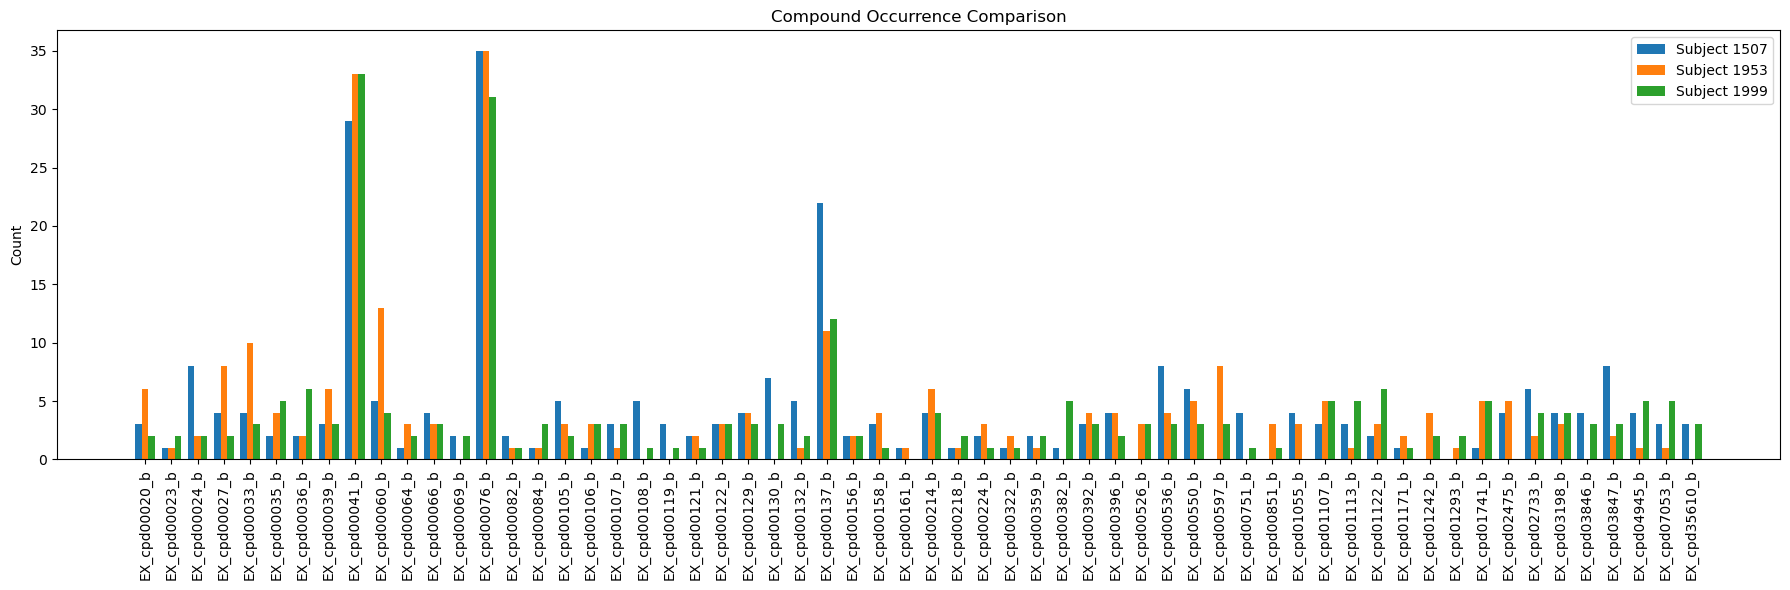

In [93]:
# Step 1: Union of all keys
all_cpds = sorted(set(sub_1507_counts) | set(sub_1953_counts) | set(sub_1999_counts))  # sorted for consistent order

# Step 2: Align counts, defaulting to 0
counts1 = [sub_1507_counts.get(cpd, 0) for cpd in all_cpds]
counts2 = [sub_1953_counts.get(cpd, 0) for cpd in all_cpds]
counts3 = [sub_1999_counts.get(cpd, 0) for cpd in all_cpds]

# Step 3: Plotting
x = np.arange(len(all_cpds))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(18, 6))  # wider figure if many cpds
ax.bar(x - width, counts1, width, label='Subject 1507')
ax.bar(x, counts2, width, label='Subject 1953')
ax.bar(x + width, counts3, width, label='Subject 1999')

# Optional: label formatting
ax.set_ylabel('Count')
ax.set_title('Compound Occurrence Comparison')
ax.set_xticks(x)
ax.set_xticklabels(all_cpds, rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

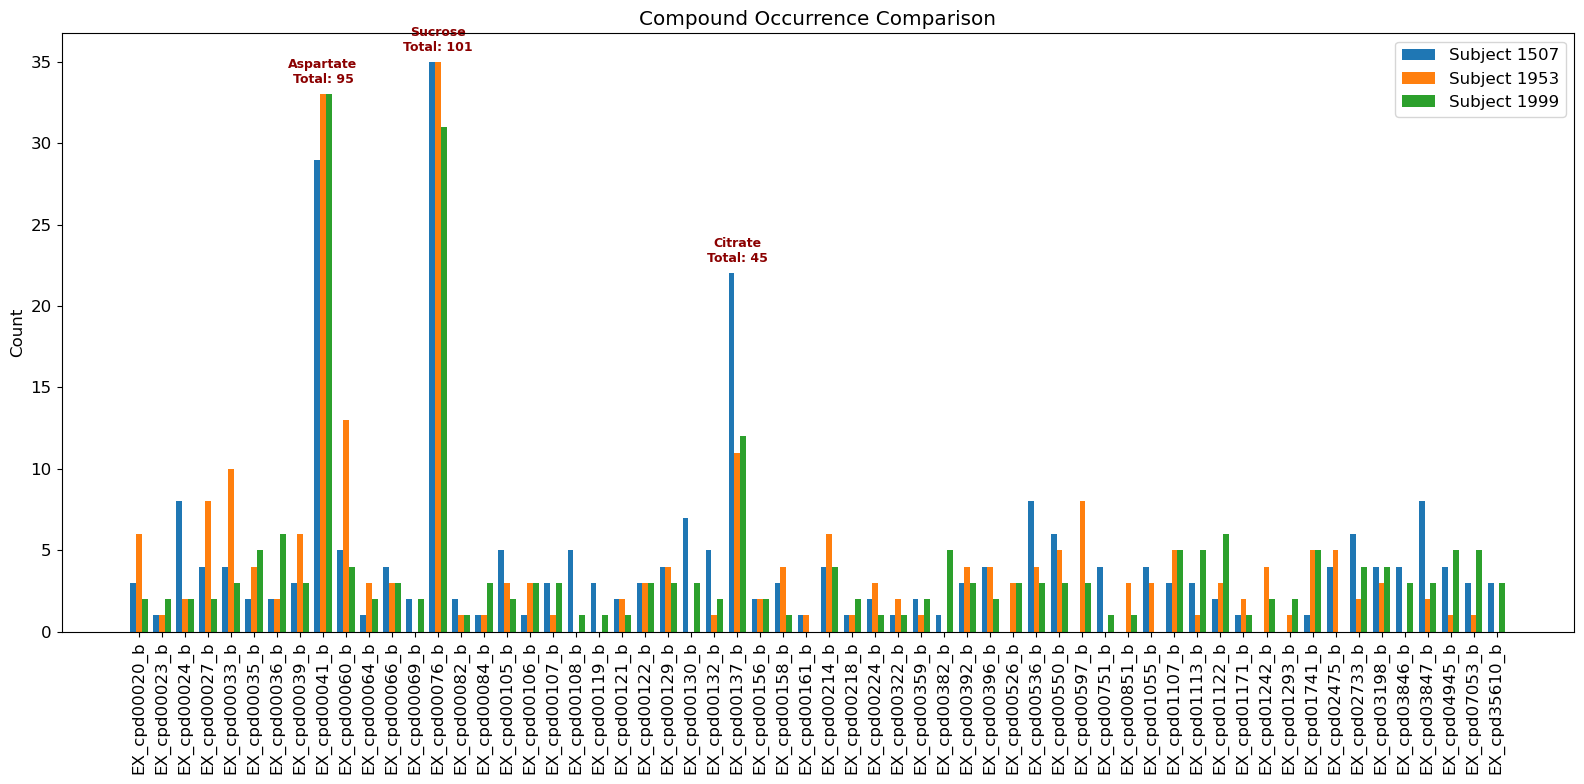

In [111]:
plt.rcParams.update({'lines.linewidth': 4})
plt.rcParams.update({'font.size': 12})


# Step 3: Compute total occurrences per cpd
total_counts = [counts1[i] + counts2[i] + counts3[i] for i in range(len(all_cpds))]

# Step 4: Find indices of top 3 compounds by total count
top3_indices = sorted(range(len(total_counts)), key=lambda i: total_counts[i], reverse=True)[:3]

# Step 5: Plot
x = np.arange(len(all_cpds))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 8))
ax.bar(x - width, counts1, width, label='Subject 1507')
ax.bar(x, counts2, width, label='Subject 1953')
ax.bar(x + width, counts3, width, label='Subject 1999')

# Labels and formatting
ax.set_ylabel('Count')
ax.set_title('Compound Occurrence Comparison')
ax.set_xticks(x)
ax.set_xticklabels(all_cpds, rotation=90)
ax.legend()

readable_cpd_name = ['Sucrose', 'Aspartate', 'Citrate']

# Step 6: Annotate top 3 compounds with total count
count = 0
for i in top3_indices:
    total = total_counts[i]
    xpos = x[i]
    name = readable_cpd_name[count]
    count +=1
    ymax = max(counts1[i], counts2[i], counts3[i])
    ax.text(xpos, ymax + .5, f'{name}\nTotal: {total}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()